To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install --no-deps transformers==5.5.0
!pip install torchcodec
import torch; torch._dynamo.config.recompile_limit = 64;

In [2]:
%%capture
!pip install --no-deps --upgrade timm # For Gemma 4 vision/audio

### Unsloth

`FastModel` supports loading nearly any model now! This includes Vision and Text models!

In [3]:
from unsloth import FastModel
import torch

gemma4_models = [
    # Gemma-4 instruct models:
    "unsloth/gemma-4-E2B-it",
    "unsloth/gemma-4-E4B-it",
    "unsloth/gemma-4-31B-it",
    "unsloth/gemma-4-26B-A4B-it",
    # Gemma-4 base models:
    "unsloth/gemma-4-E2B",
    "unsloth/gemma-4-E4B",
    "unsloth/gemma-4-31B",
    "unsloth/gemma-4-26B-A4B",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E2B-it",
    dtype = None, # None for auto detection
    max_seq_length = 1024, # Choose any for long context!
    load_in_4bit = False,  # 4 bit quantization to reduce memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "YOUR_HF_TOKEN", # HF Token for gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

# Gemma 4 can process Text, Vision and Audio!

Let's first experience how Gemma 4 can handle multimodal inputs. We use Gemma 4's recommended settings of `temperature = 1.0, top_p = 0.95, top_k = 64`

In [4]:
from transformers import TextStreamer
# Helper function for inference
def do_gemma_4_inference(messages, max_new_tokens = 128):
    _ = model.generate(
        **tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True, # Must add for generation
            tokenize = True,
            return_dict = True,
            return_tensors = "pt",
        ).to("cuda"),
        max_new_tokens = max_new_tokens,
        temperature = 1.0, top_p = 0.95, top_k = 64,
        streamer = TextStreamer(tokenizer, skip_prompt = True)
    )

Using Drive folder: /content/drive/MyDrive/gemma4vision_data
Audio source: /content/drive/MyDrive/gemma4vision_data/simple_request.mp3
Image count: 3
Image 1:


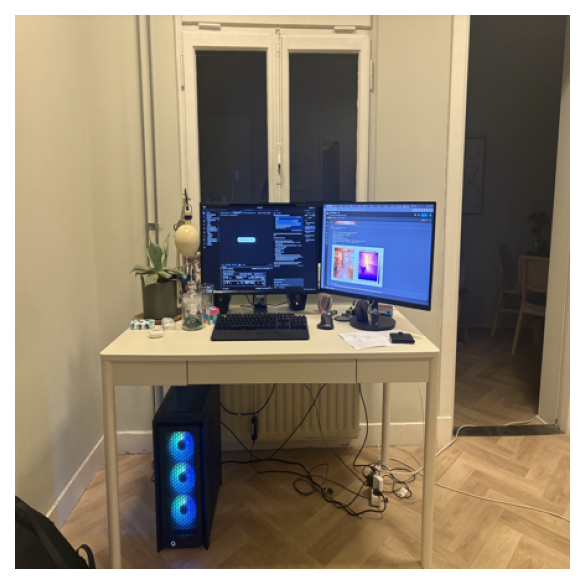

Image 2:


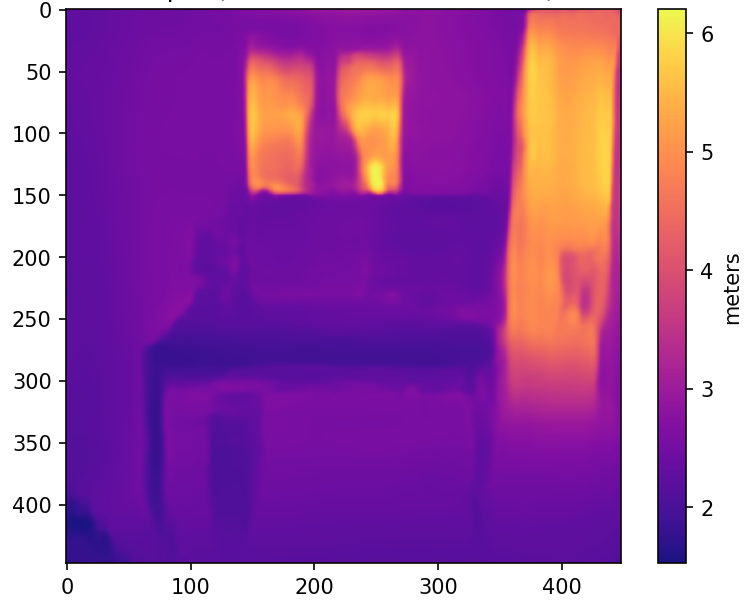

Image 3:


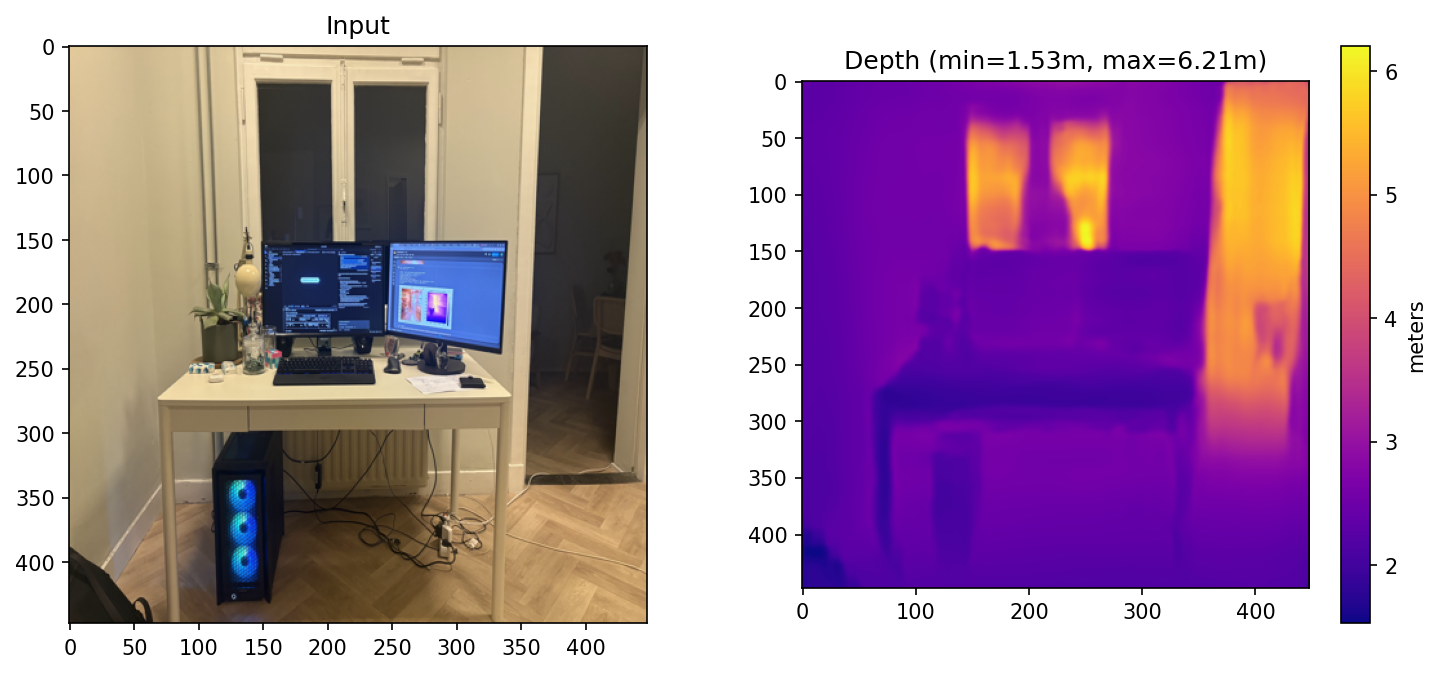

In [ ]:
from pathlib import Path
from IPython.display import Audio, Image, display
from PIL import Image as PILImage, ImageOps

# Prefer Google Drive folder, fallback to /content.
DRIVE_BASE = Path("/content/drive/MyDrive/gemma4vision_data")
CONTENT_BASE = Path("/content")

# Try mounting Drive when running in Colab.
try:
    from google.colab import drive  # type: ignore
    if not DRIVE_BASE.exists():
        drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

base_dir = DRIVE_BASE if DRIVE_BASE.exists() else CONTENT_BASE
if base_dir == DRIVE_BASE:
    print(f"Using Drive folder: {base_dir}")
else:
    print("Drive folder not found, falling back to /content")

audio_file = str(base_dir / "simple_request.mp3")
raw_rgb = base_dir / "original.png"
raw_depth = base_dir / "depth.png"
raw_depth_vis = base_dir / "depth_visualization.png"

missing = [
    p for p in [audio_file, str(raw_rgb), str(raw_depth), str(raw_depth_vis)]
    if not Path(p).exists()
]
if missing:
    raise FileNotFoundError(
        "Missing files. Expected files under "
        f"{base_dir}. Missing: {missing}"
    )

processed_dir = base_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

def _upscale_and_enhance(src_path, dst_path, min_side=896, grayscale=False):
    img = PILImage.open(src_path).convert("L" if grayscale else "RGB")
    w, h = img.size
    scale = max(1.0, float(min_side) / float(min(w, h)))
    new_size = (int(round(w * scale)), int(round(h * scale)))
    if new_size != (w, h):
        img = img.resize(new_size, PILImage.Resampling.LANCZOS)
    img = ImageOps.autocontrast(img, cutoff=1)
    if grayscale:
        img = ImageOps.equalize(img)
    img.save(dst_path)
    return str(dst_path), (w, h), new_size

proc_rgb, rgb_old, rgb_new = _upscale_and_enhance(
    raw_rgb, processed_dir / "original_enhanced.png", min_side=1024, grayscale=False
)

# Use depth visualization as the second image because it is more readable than raw depth.
proc_depth, depth_old, depth_new = _upscale_and_enhance(
    raw_depth_vis, processed_dir / "depth_vis_enhanced.png", min_side=1024, grayscale=True
)

image_files = [
    proc_rgb,
    proc_depth,
    str(raw_depth),
    str(raw_depth_vis),
]

print(f"Audio source: {audio_file}")
print(f"RGB size: {rgb_old} -> {rgb_new}")
print(f"Depth-vis size: {depth_old} -> {depth_new}")
print(f"Image count: {len(image_files)}")

for idx, image in enumerate(image_files[:4], start=1):
    print(f"Image {idx}: {Path(image).name}")
    display(Image(filename=image))
display(Audio(filename=audio_file))

# Gemma 4 can see images!


In [6]:
messages = [{
    "role": "user",
    "content": [
        { "type": "image", "image": image_files[0] },
        { "type": "text", "text": "Describe this original image." }
    ]
}]
# You might have to wait 1 minute for Unsloth's auto compiler
do_gemma_4_inference(messages, max_new_tokens = 256)

This is an indoor photograph of a desk setup, likely in a room with a white or light-colored wall and wooden flooring.

**Key elements in the image:**

*   **Desk:** A white desk serves as the central focus.
*   **Computer Setup:** On the desk, there is a computer setup featuring at least two monitors displaying what appears to be code or a dark-themed interface. A black keyboard and mouse are visible.
*   **Lighting/Decor:** To the left of the monitors, there is a small potted plant and some decorative items, including what looks like a globe or spherical object.
*   **Under the Desk:** Beneath the desk, there is a black speaker system (or a subwoofer) with blue LED lighting, and various cables are visible on the floor.
*   **Background:** The background features a doorway or opening framed by white trim. Through this opening, another room is visible, showing a wooden floor and some furniture (possibly a chair or table) in the distance. The lighting suggests an interior setting.

**Ov

Let's make a poem about sloths!

In [24]:
messages = [{
    "role": "user",
    "content": [
        { "type": "image", "image": image_files[0] },
        { "type": "image", "image": image_files[1] },
        {
            "type": "text",
            "text": (
                "Use the original RGB image and the depth image together. "
                "Identify the main objects and map an estimated distance for each object in meters. "
                "Return a concise list as: object -> distance_m."
            )
        }
    ]
}]
do_gemma_4_inference(messages, max_new_tokens = 256)

```json
[
  {"laptop": "1.0", "monitor": "1.0", "desk": "0.5", "floor": "0.1"}
]
```<turn|>


# Gemma 4 can also hear!

In [8]:
from IPython.display import Audio, display
display(Audio(url=audio_file) if audio_file.startswith(("http://", "https://")) else Audio(filename=audio_file))

In [9]:
print("Using configured audio source:", audio_file)

Using configured audio source: /content/drive/MyDrive/gemma4vision_data/simple_request.mp3


In [25]:
messages = [{
    "role": "user",
    "content": [
        { "type": "audio", "audio": audio_file },
        {
            "type": "text",
            "text": (
                "Listen to the audio carefully and respond to the exact question/task asked in it. "
                "If the audio asks for a distance, provide the answer in meters when possible."
            )
        }
    ]
}]
do_gemma_4_inference(messages, max_new_tokens = 256)

The table is four meters away.<turn|>


# Let's combine all 3 modalities together!

In [35]:
# Text-only instruction version (no audio input)
messages = [{
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": (
                "System-style instruction: Follow exactly. "
                "Inputs: image_files[0] is RGB, image_files[1] is depth. "
                "Task: Estimate the distance from the camera to the Chair in the other room. "
                "You MUST provide a best-effort numeric estimate in meters. "
                "Never answer with 'cannot be determined' or similar refusals. "
                "If uncertain, give your best estimate and lower confidence. "
                "Output only plain text in exactly this format: "
                "Task: <one sentence> | Answer: <number> m | Confidence: <low/medium/high> | Reason: <short reason>. "
                "Do not output JSON, markdown, bounding boxes, XML, code blocks, or any special tokens (including <turn|>)."
            )
        },
        { "type": "image", "image": image_files[0] },
        { "type": "image", "image": image_files[1] },
    ]
}]
do_gemma_4_inference(messages, max_new_tokens = 128)

Task: Estimate the distance from the camera to the Chair in the other room. | Answer: 4.5 m | Confidence: medium | Reason: Depth map suggests the chair is approximately 4.5 meters away.<turn|>


In [36]:
messages = [{
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": (
                "System-style instruction: You must follow this exactly. "
                "1) Listen to the audio and extract the exact task/question. "
                "2) Use the images as grounding evidence (RGB + depth). "
                "3) Complete the task from the audio using the images. "
                "4) If distance is requested, answer in meters. "
                "5) Do not return bounding boxes, JSON, or code. "
                "6) Return only plain text in this format: "
                "Task: <one sentence> | Answer: <concise answer> | "
                "Confidence: <low/medium/high> | Reason: <short reason>."
            )
        },
        { "type": "audio", "audio": audio_file },
        { "type": "image", "image": image_files[0] },
        { "type": "image", "image": image_files[1] },
        #{ "type": "image", "image": image_files[2] },
        {
            "type": "text",
            "text": (
                "Prioritize consistency with the depth image for distance estimates. "
                "If uncertain, provide best estimate and clearly state uncertainty."
            )
        }
    ]
}]
do_gemma_4_inference(messages, max_new_tokens = 256)

Task: Can you tell me how far away the table is? | Answer: 1.5 meters | Confidence: medium | Reason: The depth map indicates a distance of approximately 1.5 meters to the table.<turn|>


Likewise, if you want to instead push to GGUF to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

In [ ]:
if False: # Change to True to upload GGUF
    model.push_to_hub_gguf(
        "HF_ACCOUNT/gemma_4_finetune",
        tokenizer,
        quantization_method = "Q8_0", # Only Q8_0, BF16, F16 supported
        token = "YOUR_HF_TOKEN",
    )

Now, use the `gemma-4-finetune.gguf` file or `gemma-4-finetune-Q4_K_M.gguf` file in llama.cpp.

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
4. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://unsloth.ai/docs/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️
</div>

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).